# Week 4 – Task 1: Linear Regression (Regression Model)
**AnalystLab Africa Machine Learning Internship**

**Goal:** Build a model that predicts a numerical value — house price — based on property and area characteristics.

**Dataset:** House Prices dataset (`House-Prices.csv`) containing average area income, house age, number of rooms, number of bedrooms, area population, and price for 5,000 properties.


## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Step 2: Load Dataset

In [2]:
house_df = pd.read_csv('House-Prices.csv')
print("Shape:", house_df.shape)
house_df.head()


Shape: (5000, 7)


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price,Address
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05,USNS Raymond\nFPO AE 09386


## Step 3: Explore the Dataset

In [3]:
house_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Avg. Area Income              5000 non-null   float64
 1   Avg. Area House Age           5000 non-null   float64
 2   Avg. Area Number of Rooms     5000 non-null   float64
 3   Avg. Area Number of Bedrooms  5000 non-null   float64
 4   Area Population               5000 non-null   float64
 5   Price                         5000 non-null   float64
 6   Address                       5000 non-null   str    
dtypes: float64(6), str(1)
memory usage: 273.6 KB


In [4]:
print("Missing values per column:\n", house_df.isnull().sum())
print("\nDuplicate rows:", house_df.duplicated().sum())
house_df.describe()


Missing values per column:
 Avg. Area Income                0
Avg. Area House Age             0
Avg. Area Number of Rooms       0
Avg. Area Number of Bedrooms    0
Area Population                 0
Price                           0
Address                         0
dtype: int64

Duplicate rows: 0


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562388,5.322283,6.299250,3.140000,29403.928702,9.975771e+05
50%,68804.286404,5.970429,7.002902,4.050000,36199.406689,1.232669e+06
75%,75783.338666,6.650808,7.665871,4.490000,42861.290769,1.471210e+06
max,107701.748378,9.519088,10.759588,6.500000,69621.713378,2.469066e+06


**Notes:**
- No missing values or duplicates were found in this dataset.
- `Address` is a free-text field with no direct predictive value in its raw form, so it is dropped before modeling.

In [5]:
house_df = house_df.drop(columns=['Address'])
house_df.head()


,Avg. Area Income,Avg. Area House Age,Avg. Area Number of Rooms,Avg. Area Number of Bedrooms,Area Population,Price
0,79545.458574,5.682861,7.009188,4.09,23086.800503,1.059034e+06
1,79248.642455,6.002900,6.730821,3.09,40173.072174,1.505891e+06
2,61287.067179,5.865890,8.512727,5.13,36882.159400,1.058988e+06
3,63345.240046,7.188236,5.586729,3.26,34310.242831,1.260617e+06
4,59982.197226,5.040555,7.839388,4.23,26354.109472,6.309435e+05


### Quick EDA
A correlation heatmap helps us confirm which features are most related to Price before selecting our final feature set.

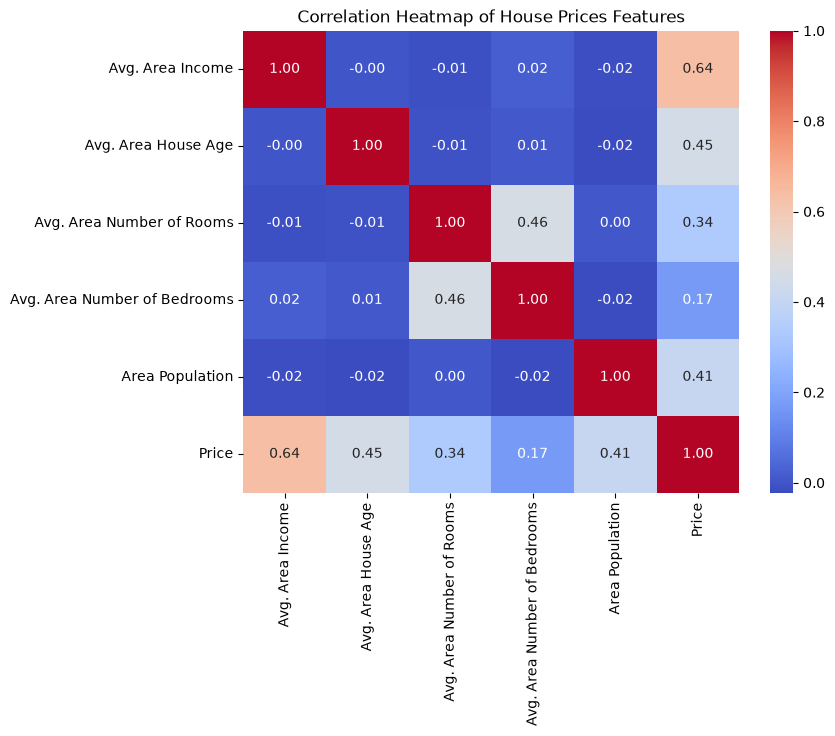

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(house_df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of House Prices Features')
plt.show()


## Step 4: Select Features and Target

- **Features (X):** Avg. Area Income, Avg. Area House Age, Avg. Area Number of Rooms, Avg. Area Number of Bedrooms, Area Population
- **Target (y):** Price

In [7]:
features = ['Avg. Area Income', 'Avg. Area House Age', 'Avg. Area Number of Rooms',
            'Avg. Area Number of Bedrooms', 'Area Population']

X = house_df[features]
y = house_df['Price']

print("Feature matrix shape:", X.shape)


Feature matrix shape: (5000, 5)


## Step 5: Split the Dataset
Using an 80/20 train/test split, as recommended in the handbook.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set:  {X_test.shape[0]} rows")


Training set: 4000 rows
Testing set:  1000 rows


#  Task 2: Logistic Regression(Classification)
**Goal**:Build a classification model that predicts whether a titanic passenger survived, using the cleaned dataset from week 1-2.

## Step 1: import libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Step 2:Load Dataset
Loading the cleaned Titanic dataset.

In [3]:
titanic_df=pd.read_csv('Titanic-Cleaned.csv')
print("Shape:",titanic_df.shape)
titanic_df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Sex_male,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",-0.565736,1,0,A/5 21171,-0.700836,True,False,True
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0.663861,1,0,PC 17599,1.491434,False,False,False
2,3,1,3,"Heikkinen, Miss. Laina",-0.258337,0,0,STON/O2. 3101282,-0.677726,False,False,True
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0.433312,1,0,113803,0.868903,False,False,True
4,5,0,3,"Allen, Mr. William Henry",0.433312,0,0,373450,-0.673447,True,False,True


## Step 3:Data Cleaning Recap
Missing values, duplicates and categorical encoding(Sex,Embarked)were already handled.Now we just drop columns that are not useful as model inputs

In [4]:
print("Missing values per column:\n", titanic_df.isnull().sum())

model_df=titanic_df.drop(columns=['PassengerId', 'Name', 'Ticket'])
model_df.head()

Missing values per column:
 PassengerId    0
Survived       0
Pclass         0
Name           0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Sex_male       0
Embarked_Q     0
Embarked_S     0
dtype: int64


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,-0.565736,1,0,-0.700836,True,False,True
1,1,1,0.663861,1,0,1.491434,False,False,False
2,1,3,-0.258337,0,0,-0.677726,False,False,True
3,1,1,0.433312,1,0,0.868903,False,False,True
4,0,3,0.433312,0,0,-0.673447,True,False,True


## Step 4: Select Fearures and Target
- Features(X):Age,Fare,Passenger Class(Pclass),Sex(Sex_male)
- Target(Y):Survived

In [5]:
features=['Age','Fare','Pclass','Sex_male']
X=model_df[features]
Y=model_df['Survived']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", Y.value_counts())

Feature matrix shape: (891, 4)
Target distribution:
 Survived
0    549
1    342
Name: count, dtype: int64


## Step 5:Split the dataset
using the 80/20 

In [6]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2, random_state=42)
print(f"Training set:{X_train.shape[0]} rows")
print(f"Testing set:{X_test.shape[0]} rows")

Training set:712 rows
Testing set:179 rows


## Step 6: Train Logistic Regression Model

In [8]:
log_model= LogisticRegression(max_iter=1000)
log_model.fit(X_train, Y_train)
print("Coefficients:", dict(zip(features, log_model.coef_[0])))

Coefficients: {'Age': np.float64(-0.32931620320135047), 'Fare': np.float64(-0.00751612652387525), 'Pclass': np.float64(-1.0399109292781799), 'Sex_male': np.float64(-2.475828137640738)}


## Step 7:Make predictions

In [9]:
Y_pred=log_model.predict(X_test)

results=pd.DataFrame({'Actual':Y_test.values, 'Predicted':Y_pred})
results.head(10)

,Actual,Predicted
0,1,0
1,0,0
2,0,0
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


## Step 8: Evaluate the Model

**Accuracy Score:** the proportion of correct predictions out of all predictions made. A higher accuracy means the model correctly classified more passengers as survived/did not survive.

We also include a confusion matrix and classification report for a fuller picture, since accuracy alone can be misleading.

Accuracy: 81.01%

Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.87      0.84       105
       Survived       0.79      0.73      0.76        74

       accuracy                           0.81       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.81      0.81       179



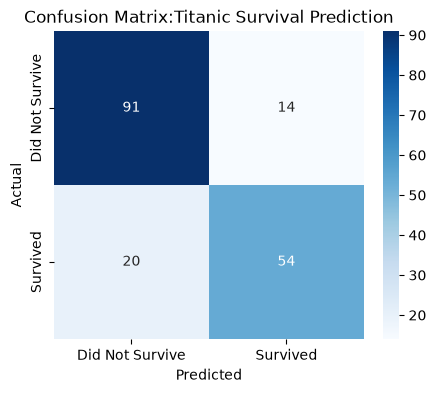

In [11]:
acc= accuracy_score(Y_test,Y_pred)
print(f"Accuracy: {acc:.2%}\n")

print("Classification Report:")
print(classification_report(Y_test,Y_pred, target_names=['Did Not Survive','Survived']))

cm=confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive','Survived'],
            yticklabels=['Did Not Survive','Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix:Titanic Survival Prediction')
plt.show()
            